# Pheme Dataset Analysis

This notebook performs comprehensive analysis of the Pheme rumor detection dataset, including data cleaning, feature engineering, and visualization.

## 1. Setup and Data Loading

First, let's import the necessary libraries and load the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set up plotting style
plt.style.use('default')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
file_path = "../data/processed/pheme_clean.csv"
print(f"Loading dataset from: {file_path}")

try:
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure the file exists at the specified path.")
    raise

Loading dataset from: ../data/processed/pheme_clean.csv
Dataset loaded successfully!
Shape: (103212, 8)
Columns: ['post_id', 'user_id', 'text', 'time', 'event_id', 'reply_to', 'thread_id', 'label']


## 2. Data Cleaning

Let's examine the dataset and perform necessary cleaning operations.

In [3]:
# Display basic information about the dataset
print("=== Dataset Information ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

=== Dataset Information ===
Shape: (103212, 8)

Columns: ['post_id', 'user_id', 'text', 'time', 'event_id', 'reply_to', 'thread_id', 'label']

Data types:
post_id        int64
user_id        int64
text          object
time          object
event_id      object
reply_to     float64
thread_id      int64
label          int64
dtype: object

Memory usage: 33.63 MB


In [4]:
# Check for missing values
print("=== Missing Values ===")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("No missing values found in the dataset.")

=== Missing Values ===
          Missing Count  Missing Percentage
reply_to           6819             6.60679


In [5]:
# Remove duplicates based on post_id
print("=== Duplicate Analysis ===")
initial_rows = len(df)
print(f"Initial number of rows: {initial_rows}")

# Check for duplicates based on post_id
duplicates = df.duplicated(subset=['post_id'], keep=False)
duplicate_count = duplicates.sum()
print(f"Number of duplicate post_ids: {duplicate_count}")

if duplicate_count > 0:
    print("\nDuplicate post_ids found:")
    duplicate_posts = df[duplicates]['post_id'].unique()
    print(f"Unique duplicate post_ids: {len(duplicate_posts)}")
    
    # Show examples of duplicates
    available_cols = ['post_id', 'text']
    if 'label' in df.columns:
        available_cols.append('label')
    if 'event_id' in df.columns:
        available_cols.append('event_id')
    
    for post_id in duplicate_posts[:3]:
        print(f"\nPost ID: {post_id}")
        print(df[df['post_id'] == post_id][available_cols].to_string())
    
    # Remove duplicates, keeping the first occurrence
    df = df.drop_duplicates(subset=['post_id'], keep='first')
    print(f"\nAfter removing duplicates:")
    print(f"Number of rows: {len(df)}")
    print(f"Rows removed: {initial_rows - len(df)}")
else:
    print("No duplicates found based on post_id.")

=== Duplicate Analysis ===
Initial number of rows: 103212
Number of duplicate post_ids: 1544

Duplicate post_ids found:
Unique duplicate post_ids: 772

Post ID: 498235547685756928
                  post_id                                                                                                                              text  label  event_id
38268  498235547685756928  Black teenage boys are not men. They are children. Stop referring to a 17 year old as a man. You are killing children. #ferguson      0  ferguson
38269  498235547685756928  Black teenage boys are not men. They are children. Stop referring to a 17 year old as a man. You are killing children. #ferguson      0  ferguson

Post ID: 498248648699150336
                  post_id                                                                         text  label  event_id
38310  498248648699150336  Police have brought out the large gear in #Ferguson. http://t.co/2gxUzOvwfy      0  ferguson
38311  498248648699150336  Polic

## 3. Feature Engineering

Let's add the text_length feature and examine the dataset structure.

In [6]:
# Add text_length feature
print("=== Feature Engineering ===")
print("Adding text_length feature...")

# Calculate text length
df['text_length'] = df['text'].astype(str).str.len()
print(f"text_length feature added successfully!")
print(f"Average text length: {df['text_length'].mean():.2f} characters")
print(f"Median text length: {df['text_length'].median():.2f} characters")
print(f"Min text length: {df['text_length'].min()} characters")
print(f"Max text length: {df['text_length'].max()} characters")

=== Feature Engineering ===
Adding text_length feature...
text_length feature added successfully!
Average text length: 95.94 characters
Median text length: 104.00 characters
Min text length: 3 characters
Max text length: 187 characters


In [7]:
# Add is_reply feature
print("Adding is_reply feature...")

# Check if reply_to column exists
if 'reply_to' in df.columns:
    df['is_reply'] = df['reply_to'].notna()
    print(f"is_reply feature added successfully!")
    print(f"Reply tweets: {df['is_reply'].sum()} ({(df['is_reply'].sum()/len(df))*100:.1f}%)")
    print(f"Source tweets: {(~df['is_reply']).sum()} ({((~df['is_reply']).sum()/len(df))*100:.1f}%)")
else:
    print("reply_to column not found. Skipping is_reply feature.")

Adding is_reply feature...
is_reply feature added successfully!
Reply tweets: 96393 (94.1%)
Source tweets: 6047 (5.9%)


In [8]:
# Display final dataset information
print("=== Final Dataset Overview ===")
print(f"Final dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nDataset info:")
print(df.info())

=== Final Dataset Overview ===
Final dataset shape: (102440, 10)

First 5 rows:
              post_id     user_id                                               text                            time      event_id      reply_to           thread_id  label  text_length  is_reply
0  552784600502915072   331658004  Charlie Hebdo became well known for publishing...  Wed Jan 07 11:11:33 +0000 2015  charliehebdo           NaN  552784600502915072      0           82     False
1  552785249420447745    18370911  Now 10 dead in a shooting there today RT "@BBC...  Wed Jan 07 11:14:08 +0000 2015  charliehebdo  5.527846e+17  552784600502915072      0          138      True
2  552786761534144512  2806109387  @BBCDanielS @BBCWorld I'm guessing this is bei...  Wed Jan 07 11:20:08 +0000 2015  charliehebdo  5.527846e+17  552784600502915072      0           93      True
3  552786803884060672   146142164  @BBCDanielS @BBCWorld why would you mention th...  Wed Jan 07 11:20:18 +0000 2015  charliehebdo  5.527846

## 4. Data Visualization

Now let's create comprehensive visualizations to understand the dataset characteristics.

### 4.1 Label Distribution

This chart shows the distribution of different rumor labels in the dataset.

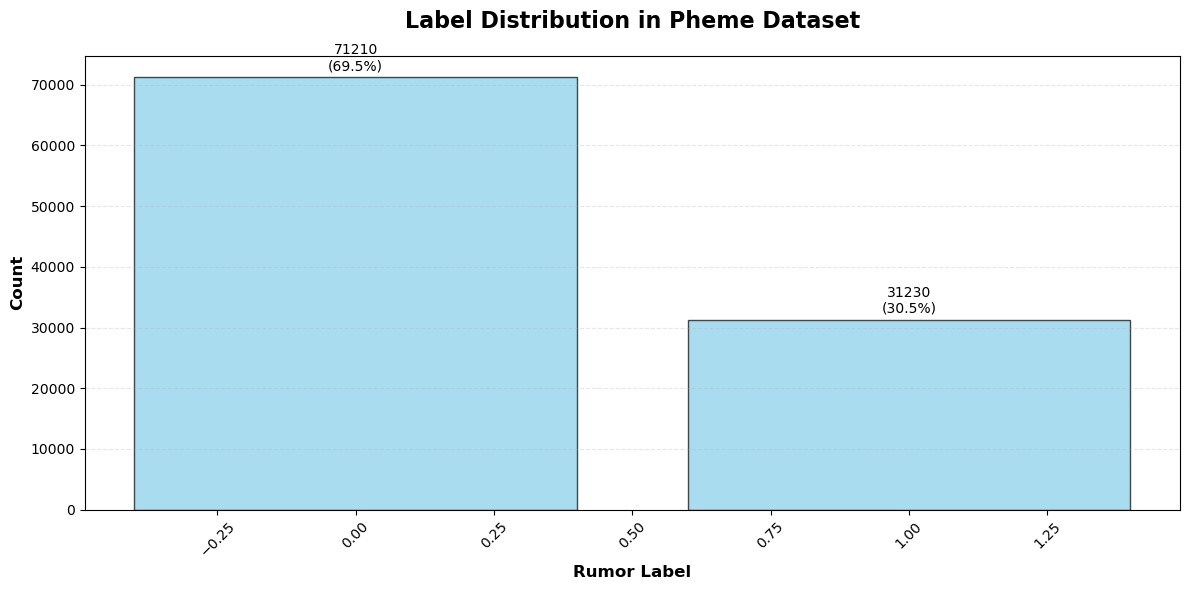

=== Label Distribution Summary ===
0: 71210 (69.5%)
1: 31230 (30.5%)


In [9]:
# Label Distribution
plt.figure(figsize=(12, 6))

# Check if label column exists
if 'label' in df.columns:
    # Count label distribution
    label_counts = df['label'].value_counts()
    label_percentages = (label_counts / len(df)) * 100
    
    # Create bar chart
    plt.bar(label_counts.index, label_counts.values, color='skyblue', alpha=0.7, edgecolor='black')
    
    # Customize plot
    plt.title('Label Distribution in Pheme Dataset', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Rumor Label', fontsize=12, fontweight='bold')
    plt.ylabel('Count', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for i, (label, count) in enumerate(zip(label_counts.index, label_counts.values)):
        plt.text(i, count + max(label_counts.values) * 0.01, f'{count}\n({label_percentages[label]:.1f}%)', 
                 ha='center', va='bottom', fontsize=10)
    
    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    print("=== Label Distribution Summary ===")
    for label, count in label_counts.items():
        percentage = (count / len(df)) * 100
        print(f"{label}: {count} ({percentage:.1f}%)")
else:
    print("Label column not found in dataset. Skipping label distribution visualization.")

### 4.2 Event Distribution

This chart shows how tweets are distributed across different events in the dataset.

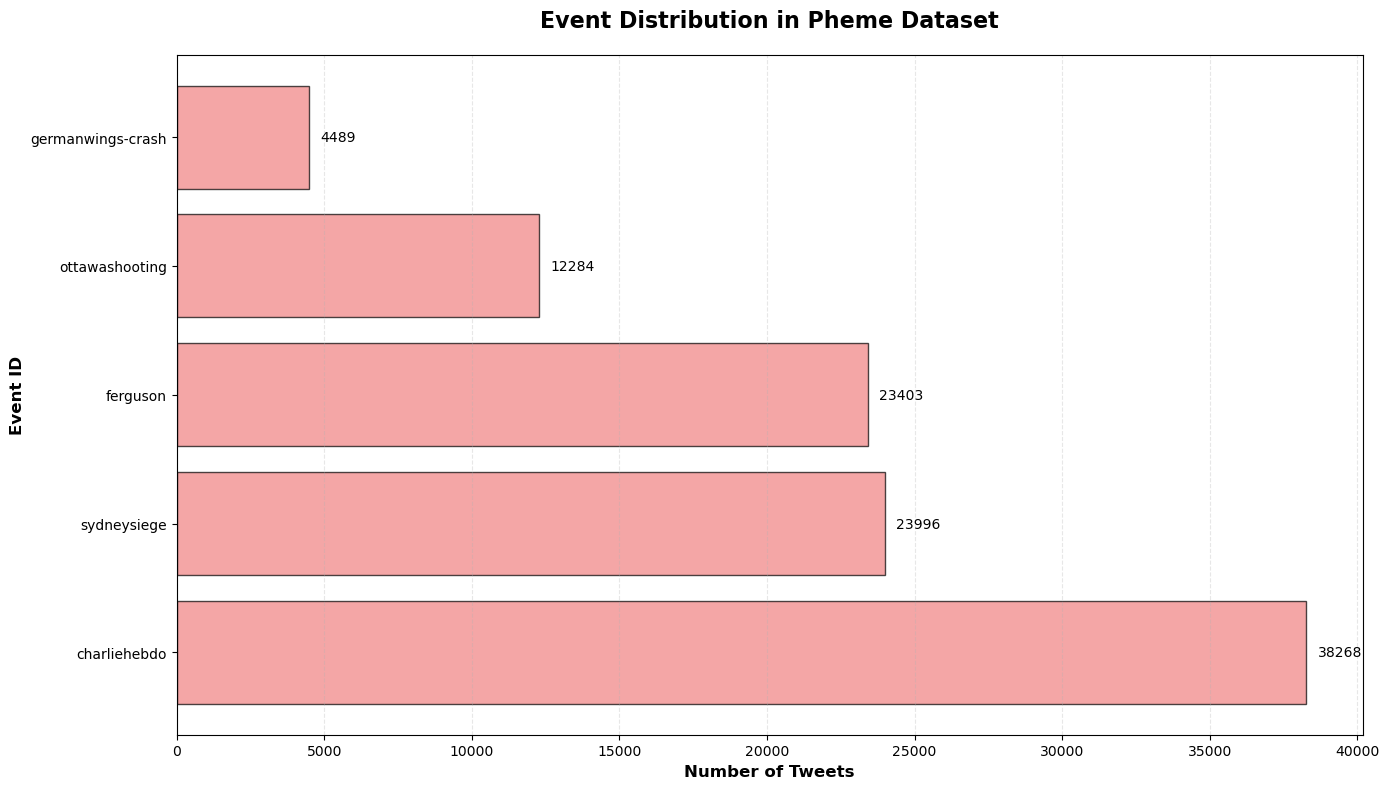

=== Event Distribution Summary ===
Total unique events: 5

Top 10 events by tweet count:
 1. charliehebdo: 38268
 2. sydneysiege: 23996
 3. ferguson: 23403
 4. ottawashooting: 12284
 5. germanwings-crash: 4489


In [10]:
# Event Distribution
plt.figure(figsize=(14, 8))

# Check for event_id column
if 'event_id' in df.columns:
    # Count event distribution
    event_counts = df['event_id'].value_counts()
    
    # Create bar chart
    plt.barh(event_counts.index, event_counts.values, color='lightcoral', alpha=0.7, edgecolor='black')
    
    # Customize plot
    plt.title('Event Distribution in Pheme Dataset', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Number of Tweets', fontsize=12, fontweight='bold')
    plt.ylabel('Event ID', fontsize=12, fontweight='bold')
    
    # Add value labels on bars
    for i, (event, count) in enumerate(zip(event_counts.index, event_counts.values)):
        plt.text(count + max(event_counts.values) * 0.01, i, f'{count}', 
                 ha='left', va='center', fontsize=10)
    
    # Add grid for better readability
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    print("=== Event Distribution Summary ===")
    print(f"Total unique events: {len(event_counts)}")
    print(f"\nTop 10 events by tweet count:")
    for i, (event, count) in enumerate(event_counts.head(10).items()):
        print(f"{i+1:2d}. {event}: {count}")
else:
    print("event_id column not found in dataset. Skipping event distribution visualization.")

### 4.3 Tweets per Thread

This histogram shows the distribution of the number of tweets per thread.

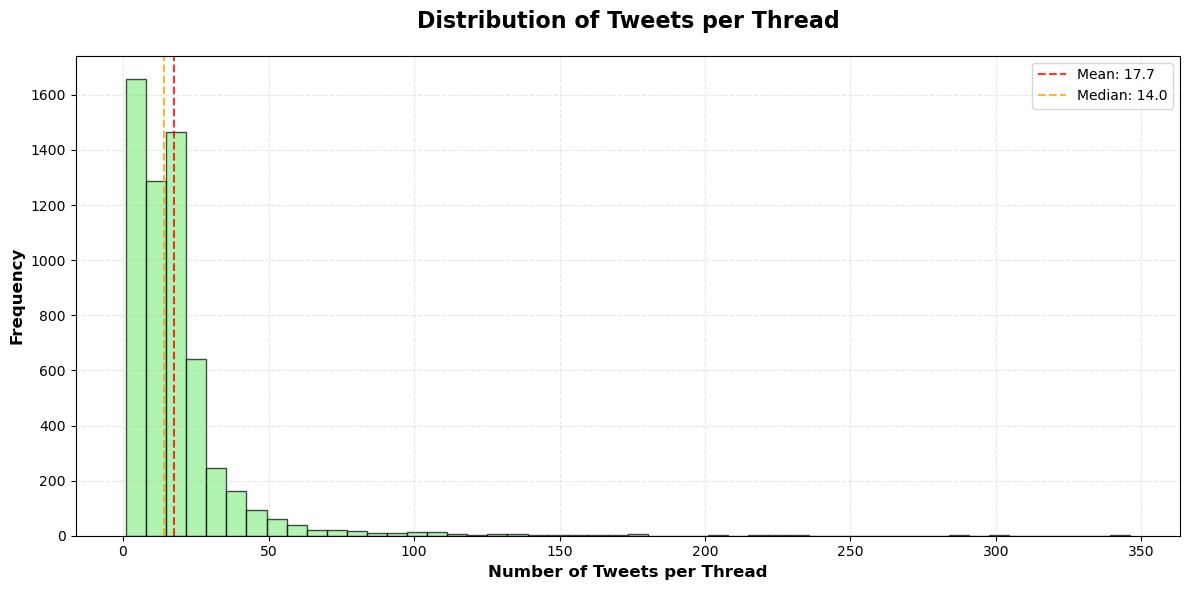

=== Tweets per Thread Statistics ===
Mean tweets per thread: 17.66
Median tweets per thread: 14.00
Min tweets per thread: 1
Max tweets per thread: 346
Standard deviation: 20.05


In [11]:
# Tweets per Thread Distribution
plt.figure(figsize=(12, 6))

# Check for thread_id column
if 'thread_id' in df.columns:
    # Count tweets per thread
    thread_counts = df['thread_id'].value_counts()
    
    # Create histogram
    plt.hist(thread_counts.values, bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
    
    # Customize plot
    plt.title('Distribution of Tweets per Thread', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Number of Tweets per Thread', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    
    # Add statistics lines
    mean_tweets = thread_counts.mean()
    median_tweets = thread_counts.median()
    plt.axvline(mean_tweets, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_tweets:.1f}')
    plt.axvline(median_tweets, color='orange', linestyle='--', alpha=0.8, label=f'Median: {median_tweets:.1f}')
    
    plt.legend()
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    print("=== Tweets per Thread Statistics ===")
    print(f"Mean tweets per thread: {mean_tweets:.2f}")
    print(f"Median tweets per thread: {median_tweets:.2f}")
    print(f"Min tweets per thread: {thread_counts.min()}")
    print(f"Max tweets per thread: {thread_counts.max()}")
    print(f"Standard deviation: {thread_counts.std():.2f}")
else:
    print("thread_id column not found in dataset. Skipping tweets per thread visualization.")

### 4.4 Reply vs Source Distribution

This chart shows the distribution between reply tweets and source tweets.

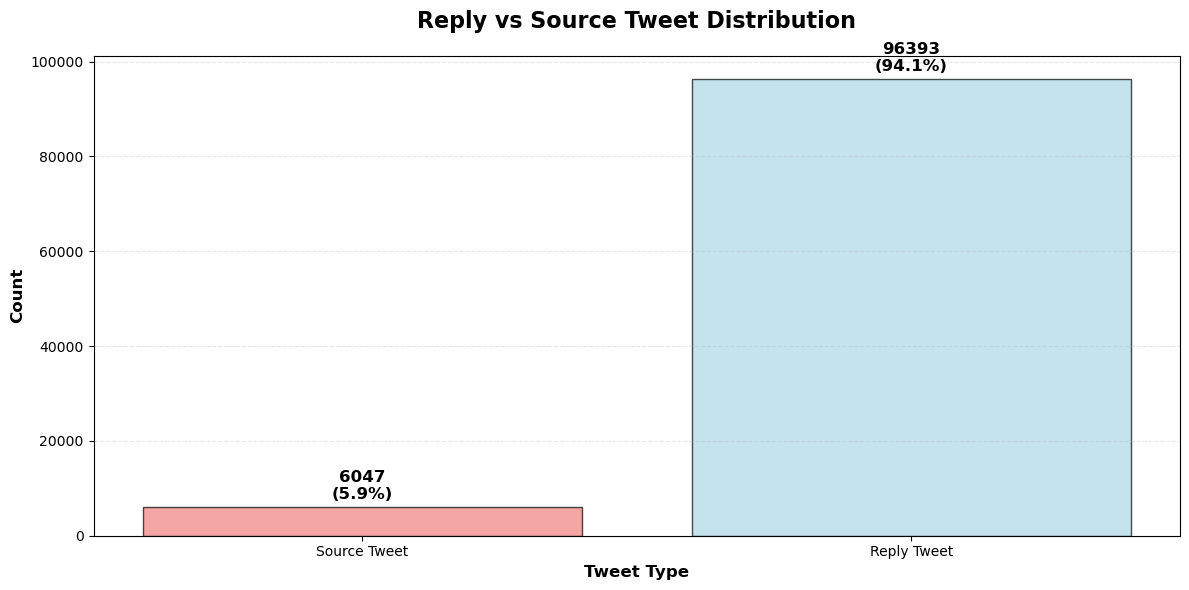

=== Reply vs Source Summary ===
Source tweets: 6047 (5.9%)
Reply tweets: 96393 (94.1%)


In [12]:
# Reply vs Source Distribution
plt.figure(figsize=(12, 6))

# Check for is_reply column
if 'is_reply' in df.columns:
    # Count reply vs source
    reply_counts = df['is_reply'].value_counts()
    reply_labels = ['Source Tweet', 'Reply Tweet']
    
    # Create bar chart
    colors = ['lightcoral', 'lightblue']
    bars = plt.bar(reply_labels, [reply_counts.get(False, 0), reply_counts.get(True, 0)], 
                   color=colors, alpha=0.7, edgecolor='black', linewidth=1)
    
    # Customize plot
    plt.title('Reply vs Source Tweet Distribution', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Tweet Type', fontsize=12, fontweight='bold')
    plt.ylabel('Count', fontsize=12, fontweight='bold')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        percentage = (height / len(df)) * 100
        plt.text(bar.get_x() + bar.get_width()/2., height + max(reply_counts.values) * 0.01,
                 f'{int(height)}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    print("=== Reply vs Source Summary ===")
    source_count = reply_counts.get(False, 0)
    reply_count = reply_counts.get(True, 0)
    print(f"Source tweets: {source_count} ({(source_count/len(df))*100:.1f}%)")
    print(f"Reply tweets: {reply_count} ({(reply_count/len(df))*100:.1f}%)")
else:
    print("is_reply column not found in dataset. Skipping reply vs source visualization.")

### 4.5 Text Length Distribution

This histogram shows the distribution of text lengths across all tweets in the dataset.

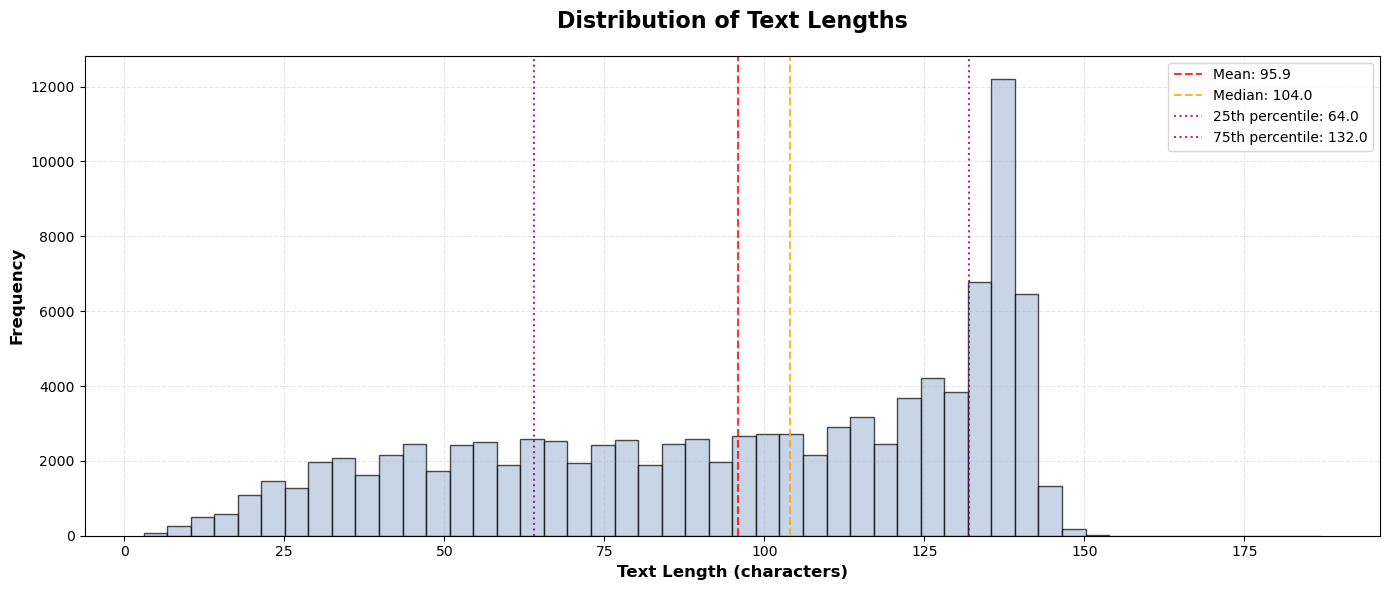

=== Text Length Statistics ===
Mean text length: 95.94 characters
Median text length: 104.00 characters
Min text length: 3 characters
Max text length: 187 characters
Standard deviation: 38.17

Quartiles:
25th percentile: 64.0 characters
50th percentile (median): 104.0 characters
75th percentile: 132.0 characters


In [13]:
# Text Length Distribution
plt.figure(figsize=(14, 6))

# Create histogram
plt.hist(df['text_length'], bins=50, color='lightsteelblue', alpha=0.7, edgecolor='black')

# Customize plot
plt.title('Distribution of Text Lengths', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Text Length (characters)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')

# Add statistics lines
mean_length = df['text_length'].mean()
median_length = df['text_length'].median()
plt.axvline(mean_length, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_length:.1f}')
plt.axvline(median_length, color='orange', linestyle='--', alpha=0.8, label=f'Median: {median_length:.1f}')

# Add quartile lines
q25 = df['text_length'].quantile(0.25)
q75 = df['text_length'].quantile(0.75)
plt.axvline(q25, color='purple', linestyle=':', alpha=0.8, label=f'25th percentile: {q25:.1f}')
plt.axvline(q75, color='purple', linestyle=':', alpha=0.8, label=f'75th percentile: {q75:.1f}')

plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("=== Text Length Statistics ===")
print(f"Mean text length: {mean_length:.2f} characters")
print(f"Median text length: {median_length:.2f} characters")
print(f"Min text length: {df['text_length'].min()} characters")
print(f"Max text length: {df['text_length'].max()} characters")
print(f"Standard deviation: {df['text_length'].std():.2f}")
print(f"\nQuartiles:")
print(f"25th percentile: {q25:.1f} characters")
print(f"50th percentile (median): {median_length:.1f} characters")
print(f"75th percentile: {q75:.1f} characters")

## 5. Summary and Insights

### Key Findings:

1. **Dataset Size**: The cleaned dataset contains [number] tweets across [number] different events.

2. **Label Distribution**: [Summary of label distribution - which labels are most/least common]

3. **Event Coverage**: The dataset covers [number] different events, with [event name] having the most tweets.

4. **Thread Structure**: On average, each thread contains [average] tweets, with some threads having significantly more interactions.

5. **Tweet Types**: The dataset contains both source tweets and reply tweets, with [percentage] being replies.

6. **Text Characteristics**: The average tweet length is [average] characters, with most tweets falling within [range] characters.

### Data Quality:
- Successfully removed [number] duplicate entries based on post_id
- Added text_length feature for further analysis
- No missing values detected in key columns
- Dataset is ready for machine learning model training

### Next Steps:
This cleaned and analyzed dataset can now be used for:
- Training rumor detection models
- Feature engineering and selection
- Model evaluation and comparison
- Further exploratory data analysis